In [1]:
import matplotlib.pyplot as plt
import numpy as np
from tapas_gmm_modified.policy.models.tpgmm import (
    ReconstructionStrategy, 
    ModelType,
    FittingStage,
    InitStrategy,
    TPGMMConfig,
    AutoTPGMMConfig,
    AutoTPGMM,
    FrameSelectionConfig,
    DemoSegmentationConfig,
    CascadeConfig,
)

from tapas_gmm_modified.dataset.demos import Demos
from tapas_gmm_modified.viz.gmm import plot_hmm_transition_matrix

np.set_printoptions(precision=2)

plt.style.use('default')

from matplotlib import rc
rc('animation', html='jshtml')

2026-06-22 00:51:55.662 | INFO     |  Running on cpu


/home/jangruhnert/miniconda3/envs/hecarim/lib/python3.10/site-packages/riepybdlib/data.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_listdir


In [2]:
from pathlib import Path

import h5py
from heca.scenes.scene import Scene
from heca.scenes.ogbench.scene import OGBenchScene

from heca.agents.experts.expert import ExpertAgent
from heca.agents.experts.tapas import TapasAgent

scene_cfg = OGBenchScene.Config()
agent_cfg = TapasAgent.Config(
    folder="move_ee",
    scene=scene_cfg,
    use_gt=True,
)
scene = Scene.get(scene_cfg, load=False)
agent = TapasAgent.get(agent_cfg, load=False)
agent_dir = ExpertAgent.resolve(agent_cfg)
model_file_name = "policy_gt.pt" if agent_cfg.use_gt else "policy_img.pt"
file_path = Path.cwd().parent.parent.parent / agent_dir / "demos_post_new.h5"
save_path = Path.cwd().parent.parent.parent / agent_dir / model_file_name
print(agent_dir)
print(file_path)
print(save_path)

2026-06-22 00:51:56.844 | INFO     | heca.misc.logger:info:30 - Running on cpu


/home/jangruhnert/miniconda3/envs/hecarim/lib/python3.10/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/jangruhnert/miniconda3/envs/hecarim/lib/python3.10/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


data/experts/tapas/move_ee
/home/jangruhnert/Documents/GitHub/master-project/data/experts/tapas/move_ee/demos_post_new.h5
/home/jangruhnert/Documents/GitHub/master-project/data/experts/tapas/move_ee/policy_gt.pt


In [3]:
from tensordict import TensorDict
from tapas_gmm_modified.utils.observation import SceneObservation

demos_file = h5py.File(file_path, "r")
# load observations here
print(demos_file.keys())
observations: list[SceneObservation] = []  # type: ignore

demos_scenes, demos_images = scene.load_dataset(demos_file)

for i, (demo_scenes, demo_images) in enumerate(zip(demos_scenes, demos_images)):
    if agent_cfg.use_gt:
        obss: list[TensorDict] = []
        for td_scene in demo_scenes:
            td_obs = td_scene
            td_goal = demo_scenes[-1]
            obs = agent.tapas_td(td_obs, td_goal)
            obss.append(obs)
        stacked_obs = TensorDict.stack(obss, dim=0)
        observations.append(stacked_obs)
    else:
        raise NotImplementedError(
            "TODO: implement tapas_td and convert demos to tapas format"
        )
        # TODO:

<KeysViewHDF5 ['actions', 'button_states', 'control', 'demo', 'depth', 'extrinsics', 'intrinsics', 'mask', 'prev_button_states', 'prev_qpos', 'prev_qvel', 'privileged_block_0_pos', 'privileged_block_0_quat', 'privileged_block_0_state', 'privileged_block_0_yaw', 'privileged_button_0_pos', 'privileged_button_0_pos_full', 'privileged_button_0_quat', 'privileged_button_0_state', 'privileged_button_0_vel', 'privileged_button_1_pos', 'privileged_button_1_pos_full', 'privileged_button_1_quat', 'privileged_button_1_state', 'privileged_button_1_vel', 'privileged_drawer_handle_pos', 'privileged_drawer_handle_quat', 'privileged_drawer_handle_state', 'privileged_drawer_handle_yaw', 'privileged_drawer_pos', 'privileged_drawer_vel', 'privileged_target_block', 'privileged_target_block_pos', 'privileged_target_block_quat', 'privileged_target_block_yaw', 'privileged_target_button', 'privileged_target_button_quat', 'privileged_target_button_state', 'privileged_target_button_top_pos', 'privileged_target_

In [4]:
data_kwargs = dict(
    add_init_ee_pose_as_frame=True,
    add_world_frame=False,
    frames_from_keypoints=False,
    kp_indeces=None,
    enforce_z_up=False,
    modulo_object_z_rotation=False,
    make_quats_continuous=True,
)

demos = Demos(observations, **data_kwargs) #type: ignore
print("n_trajs", demos.n_trajs)
print("n_frames", demos.n_frames)
demos.frame_names

2026-06-22 00:52:01.085 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 9 using strategy mean-length.
n_trajs 10
n_frames 8


('ee_init',
 'drawer_handle',
 'window_handle',
 'button_0',
 'button_1',
 'block_0',
 'block_0_target',
 'ee_target')

In [5]:
frame_selection_config = FrameSelectionConfig(
    init_strategy=InitStrategy.TIME_BASED,
    fitting_actions=(FittingStage.INIT,),
    use_bic=False,
    drop_redundant_frames=False,
    rel_score_threshold=0.0,
    gt_frames=[[0, 7]],  # Frames per segment
)

tpgmm_config = TPGMMConfig(
    n_components=20,
    model_type=ModelType.HMM,
    use_riemann=True,
    add_time_component=True,
    add_action_component=False,
    position_only=False,
    add_gripper_action=False,
    reg_shrink=1e-2,
    reg_diag=2e-4,
    reg_diag_gripper=2e-2,
    reg_em_finish_shrink=1e-2,
    reg_em_finish_diag=2e-4,
    reg_em_finish_diag_gripper=2e-2,
    trans_cov_mask_t_pos_corr=False,
    em_steps=50,
    fix_first_component=False,  # True maybe
    fix_last_component=False,  # True maybe
    reg_init_diag=5e-4,  # 5
    heal_time_variance=False,
)

demos_segmentation_config = DemoSegmentationConfig(
    gripper_based=False,
    distance_based=False,
    velocity_based=True,
    repeat_final_step=0, #1
    repeat_first_step=0,
    components_prop_to_len=True,
    velocity_threshold=0.1,
)

cascade_config = CascadeConfig(
    kl_keep_time_dim=True,
    kl_keep_rotation_dim=False,
)

auto_tpgmm_config = AutoTPGMMConfig(
    tpgmm=tpgmm_config,
    frame_selection=frame_selection_config,
    demos_segmentation=demos_segmentation_config,
    cascade=cascade_config,
)

In [6]:
atpgmm = AutoTPGMM(auto_tpgmm_config)


2026-06-22 00:52:01.112 | INFO     | tapas_gmm_modified.policy.models.tpgmm:fit_trajectories:2740 - Fitting AutoTPGMM
2026-06-22 00:52:01.112 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [INIT]
2026-06-22 00:52:01.112 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_segment_and_frame_select:2860 - Segmenting trajectories


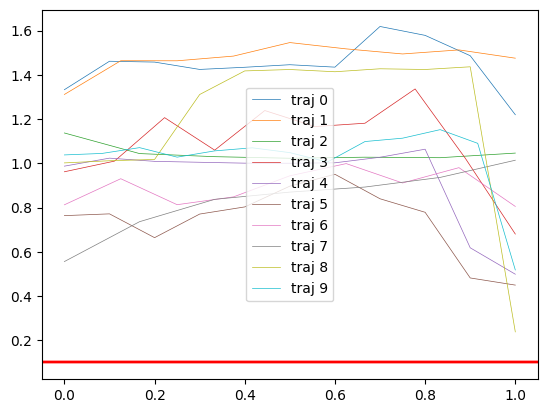

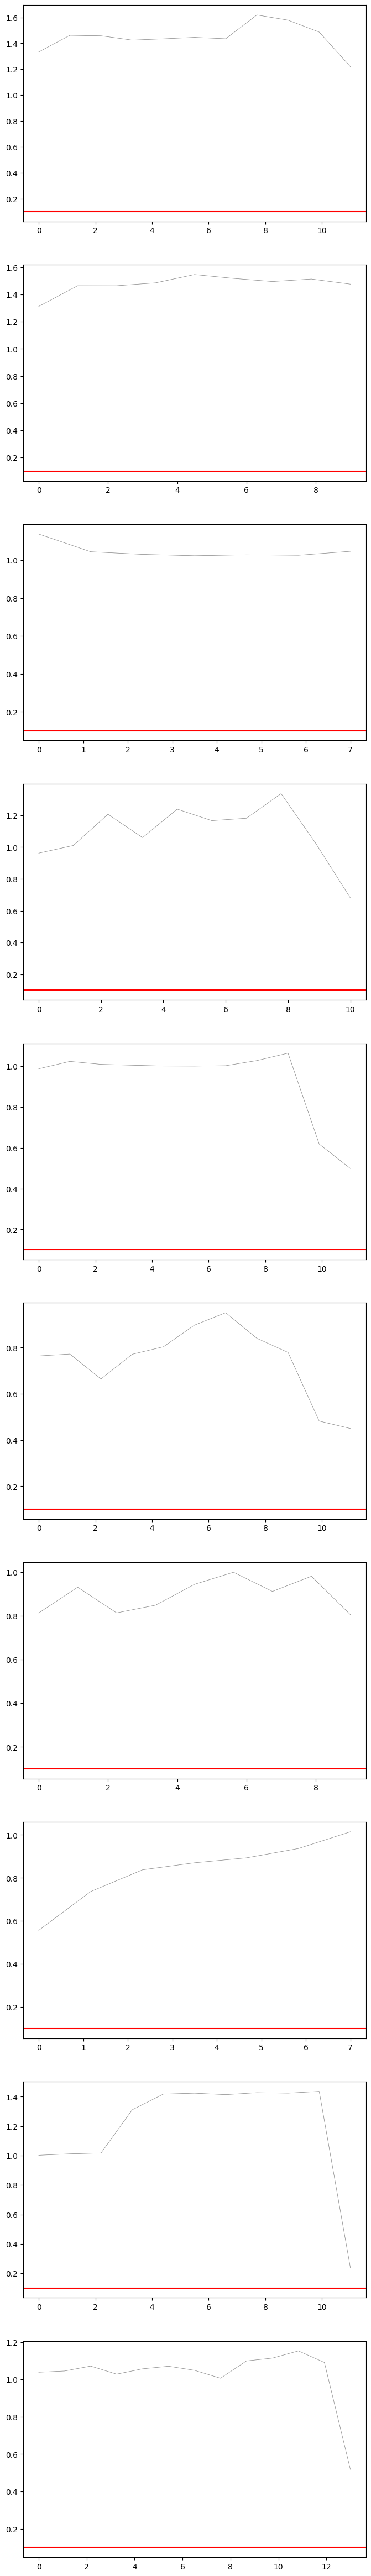

2026-06-22 00:52:01.758 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2697 - Creating segement of demos.
2026-06-22 00:52:01.759 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 9 using strategy mean-length.
2026-06-22 00:52:01.759 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_segment_and_frame_select:2865 - ... created 1 segments
2026-06-22 00:52:01.760 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_frames:3043 - Fitting candidate frame 1/8
2026-06-22 00:52:01.760 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2470 - Creating partial frame view of demos.
2026-06-22 00:52:01.760 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 9 using strategy mean-length.
2026-06-22 00:52:01.761 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_setup_manifold:735 - Manifold: TIME x R3 x QUAT
2026-06-22 00:52:01.761 | INFO     | riepybdlib.statistics:set_n_compone

Time-based init:   0%|          | 0/22 [00:00<?, ?it/s]

2026-06-22 00:52:01.838 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_frames:3043 - Fitting candidate frame 2/8
2026-06-22 00:52:01.839 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2470 - Creating partial frame view of demos.
2026-06-22 00:52:01.839 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 9 using strategy mean-length.
2026-06-22 00:52:01.841 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_setup_manifold:735 - Manifold: TIME x R3 x QUAT
2026-06-22 00:52:01.841 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 22
2026-06-22 00:52:01.841 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [INIT]
2026-06-22 00:52:01.841 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_init:1195 - Model init ...


Time-based init:   0%|          | 0/22 [00:00<?, ?it/s]

2026-06-22 00:52:01.937 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_frames:3043 - Fitting candidate frame 3/8
2026-06-22 00:52:01.937 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2470 - Creating partial frame view of demos.
2026-06-22 00:52:01.937 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 9 using strategy mean-length.
2026-06-22 00:52:01.939 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_setup_manifold:735 - Manifold: TIME x R3 x QUAT
2026-06-22 00:52:01.939 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 22
2026-06-22 00:52:01.939 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [INIT]
2026-06-22 00:52:01.939 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_init:1195 - Model init ...


...

2026-06-22 00:52:02.546 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_frames:3009 - ee_init    score (rel):     -1 (1.000)
2026-06-22 00:52:02.546 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_frames:3009 - drawer_handle score (rel):     -0 (0.125)
2026-06-22 00:52:02.546 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_frames:3009 - window_handle score (rel):     -0 (0.125)
2026-06-22 00:52:02.546 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_frames:3009 - button_0   score (rel):     -0 (0.125)
2026-06-22 00:52:02.546 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_frames:3009 - button_1   score (rel):     -0 (0.125)
2026-06-22 00:52:02.546 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_frames:3009 - block_0    score (rel):     -0 (0.125)
2026-06-22 00:52:02.546 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_frames:3009 - block_0_target score (rel):     -0 (0.125)
2026-06-22 00:52:02.546 | INFO 

Fitting segments:   0%|          | 0/1 [00:00<?, ?it/s]

2026-06-22 00:52:02.563 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_setup_manifold:735 - Manifold: TIME x R3 x QUAT x R3 x QUAT
2026-06-22 00:52:02.563 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 22
2026-06-22 00:52:02.563 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [INIT]
2026-06-22 00:52:02.564 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_init:1195 - Model init ...


Time-based init:   0%|          | 0/22 [00:00<?, ?it/s]

((array([[1.14e+011, 2.72e+002, 1.64e-024, ..., 1.19e-318, 0.00e+000,
          0.00e+000],
         [9.74e-042, 6.86e-040, 9.93e-057, ..., 1.37e-319, 0.00e+000,
          0.00e+000],
         [1.85e+002, 1.43e+011, 2.69e+002, ..., 1.89e-217, 8.17e-315,
          0.00e+000],
         ...,
         [0.00e+000, 0.00e+000, 7.32e-228, ..., 9.37e+001, 1.03e+011,
          3.21e+001],
         [9.74e-042, 6.86e-040, 9.93e-057, ..., 1.37e-319, 0.00e+000,
          0.00e+000],
         [9.74e-042, 6.86e-040, 9.93e-057, ..., 1.37e-319, 0.00e+000,
          0.00e+000]]),),
 (-23.22127538827227,))

In [7]:
atpgmm.fit_trajectories(demos, fix_frames=True,
                       init_strategy=InitStrategy.TIME_BASED,
                       fitting_actions=(FittingStage.INIT,)) # FittingStage.EM_HMM))


2026-06-22 00:52:02.746 | INFO     | tapas_gmm_modified.policy.models.tpgmm:plot_model:3856 - Did not specify time_based, deciding automatically.


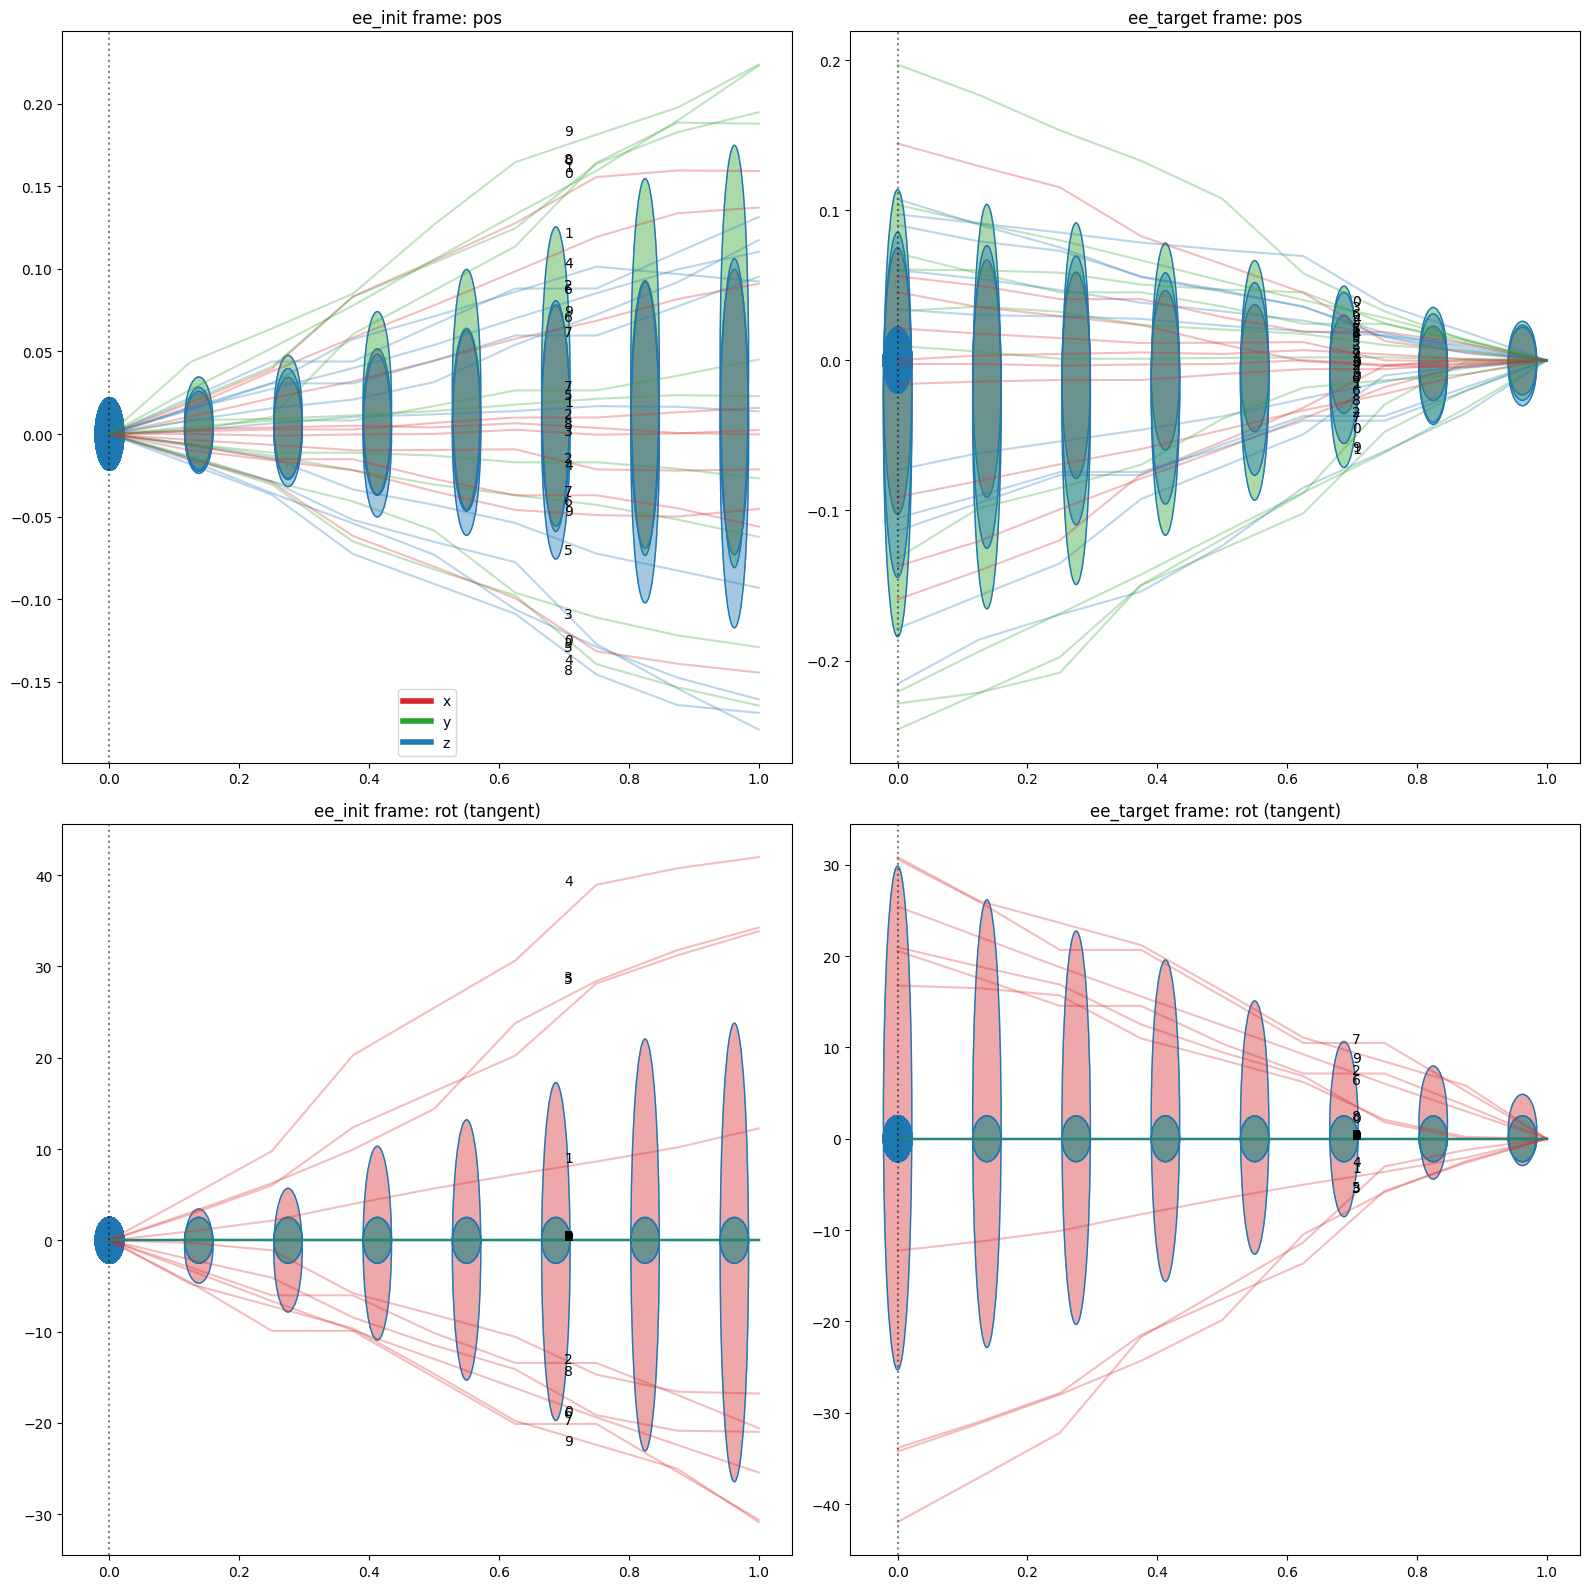

In [8]:
atpgmm.plot_model(
    scatter=True, rotations_raw=True, plot_traj=True, plot_gaussians=True,
    annotate_gaussians=False, annotate_trajs=True,
    mean_as_base=False, per_segment=False, gaussian_mean_only=False, plot_traj_means=False) #, size=(150, 10))


In [9]:
atpgmm.fit_trajectories(demos, fix_frames=True,
                       fitting_actions=(FittingStage.EM_HMM, ))


2026-06-22 00:52:03.960 | INFO     | tapas_gmm_modified.policy.models.tpgmm:fit_trajectories:2740 - Fitting AutoTPGMM
2026-06-22 00:52:03.961 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [EM_HMM]


Fitting segments:   0%|          | 0/1 [00:00<?, ?it/s]

2026-06-22 00:52:03.964 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [EM_HMM]
2026-06-22 00:52:03.964 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_hmm:1296 - HMM EM ...
2026-06-22 00:52:03.968 | INFO     | riepybdlib.statistics:trans:1710 - HMM transition matrix not defined, initializing to uniform


HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

2026-06-22 00:52:03.984 | INFO     | riepybdlib.statistics:init_priors:1698 - HMM init priors not defined, initializing to uniform


/home/jangruhnert/miniconda3/envs/hecarim/lib/python3.10/site-packages/riepybdlib/statistics.py:1996: RuntimeWarning: overflow encountered in multiply
  beta[:, t] = np.dot(self.Trans, beta[:, t + 1] * B[:, t + 1])
/home/jangruhnert/miniconda3/envs/hecarim/lib/python3.10/site-packages/riepybdlib/statistics.py:1999: RuntimeWarning: overflow encountered in multiply
  beta[:, t] = np.minimum(beta[:, t] * c[t], 1)
/home/jangruhnert/miniconda3/envs/hecarim/lib/python3.10/site-packages/riepybdlib/statistics.py:2235: RuntimeWarning: invalid value encountered in divide
  self.Trans /= np.sum(self.Trans, axis=1, keepdims=True)


ValueError: Nan in Trans

In [ ]:

atpgmm.plot_model(
    scatter=True, rotations_raw=True, plot_traj=True, plot_gaussians=True,
    annotate_gaussians=False, annotate_trajs=False,
    mean_as_base=False, per_segment=False, gaussian_mean_only=False, plot_traj_means=False)

In [ ]:
atpgmm.plot_model(
    scatter=True, rotations_raw=True, plot_traj=True, plot_gaussians=False,
    annotate_gaussians=True, annotate_trajs=False,
    mean_as_base=False, per_segment=False, gaussian_mean_only=False, plot_traj_means=False, time_based=False)

In [ ]:
atpgmm.plot_hmm_transition_matrix()

In [ ]:
atpgmm.to_disk(save_path) # type: ignore

In [ ]:
seg_local_marginals, seg_trans_marginals, seg_trans_marg_container, seg_joint_models, cascaded_hmms, (reconstructions, original_trajectories, extras) = atpgmm.reconstruct(
    strategy=ReconstructionStrategy.GMR,
    use_ss=False)


In [ ]:
for cascaded_hmm in cascaded_hmms:
    plot_hmm_transition_matrix(cascaded_hmm)

In [ ]:

atpgmm.plot_reconstructions(
    seg_trans_marg_container, cascaded_hmms, reconstructions, original_trajectories,
    plot_trajectories=True, plot_reconstructions=True, plot_gaussians=True,
    time_based=True, equal_aspect=False, per_segment=False)


In [ ]:
atpgmm.plot_reconstructions(
    seg_trans_marginals, seg_joint_models, reconstructions, original_trajectories,
    plot_trajectories=True, plot_reconstructions=True, plot_gaussians=True,
    time_based=False, equal_aspect=True, per_segment=False)
